# Fig 5

Local data analysis and visualization based on the autoencoder results


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

font = FontProperties()
font.set_family("serif")
font.set_name("Times New Roman")
font.set_size(8)

plt.rcParams["figure.figsize"] = [3, 4]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]
sns.set(style="white")
sns.set_context("paper", rc={"font.size": 8, "axes.titlesize": 8, "axes.labelsize": 8})

FACTOR_COLOR = {
    "struc": "#3bc0cf",
    "env": "#0c7cba",
    "home": "#cfd1c2",
    "who": "#ef5c43",
    "behavior": "#b1d6f0",
}
CITY_DICT = {
    "boston": "Boston",
    "chicago": "Chicago",
    "hongkong": "Hong Kong",
    "london": "London",
    "saopaulo": "Sao Paulo",
}
type_colors = {
    "visit_only": "#3ec1cf",
    "visit_person": "#b2d6f0",
    "home_only": "#ef5c43",
    "home_person": "#f9aba0",
    "person_only": "#7f7f7f",
}
income_dict = {"1": "L", "2": "ML", "3": "MH", "4": "H"}
city_enum = ["boston", "chicago", "hongkong", "london", "saopaulo"]
type_colors_update = {
    "visit_only": "#3ec1cf",
    "visit_person": "#3ec1cf",
    "home_only": "#ef5c43",
    "home_person": "#ef5c43",
}
CONFIG_LS = ["15minw", "15min", "1260m", "1260mw"]


def resolve_data_dir() -> Path:
    candidates = [Path.cwd() / "data", Path.cwd().parent / "data"]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not find the local data/ directory")


def load_exposure_results(data_dir: Path, suffix: str = "") -> pd.DataFrame:
    frames = []
    for config_load in CONFIG_LS:
        filename = f"poi_exposure_osm_all_fpTrue_wm=osm_{config_load}{suffix}.csv"
        path = data_dir / filename
        if not path.exists():
            print(f"Skipping missing file: {filename}")
            continue
        temp = pd.read_csv(path)
        temp["config"] = config_load
        frames.append(temp)
    if not frames:
        raise FileNotFoundError("No local poi exposure CSV files were found in data/")
    return pd.concat(frames, ignore_index=True)


def concat_result(result_df: pd.DataFrame):
    visit_only = result_df[
        (result_df["zero_visit"] == False)
        & (result_df["zero_home"] == True)
        & (result_df["zero_person"] == True)
    ].reset_index(drop=True)
    visit_only["type"] = "visit_only"

    home_only = result_df[
        (result_df["zero_visit"] == True)
        & (result_df["zero_home"] == False)
        & (result_df["zero_person"] == True)
    ].reset_index(drop=True)
    home_only["type"] = "home_only"

    person_only = result_df[
        (result_df["zero_visit"] == True)
        & (result_df["zero_home"] == True)
        & (result_df["zero_person"] == False)
    ].reset_index(drop=True)
    person_only["type"] = "person_only"

    home_person = result_df[
        (result_df["zero_visit"] == True)
        & (result_df["zero_home"] == False)
        & (result_df["zero_person"] == False)
    ].reset_index(drop=True)
    home_person["type"] = "home_person"

    visit_person = result_df[
        (result_df["zero_visit"] == False)
        & (result_df["zero_home"] == True)
        & (result_df["zero_person"] == False)
    ].reset_index(drop=True)
    visit_person["type"] = "visit_person"

    viz_df = pd.concat(
        [visit_only, home_only, person_only, home_person, visit_person],
        axis=0,
    ).reset_index(drop=True)
    viz_df_sel = viz_df[viz_df["split"] != "random"].reset_index(drop=True)
    baseline_sel = viz_df[viz_df["split"] == "random"].reset_index(drop=True)
    return viz_df_sel, baseline_sel


data_dir = resolve_data_dir()
DF = load_exposure_results(data_dir)
viz_df_sel, baseline_sel = concat_result(DF)

print(f"Loaded {len(DF):,} rows from {data_dir}")
print(sorted(DF['config'].unique()))
print(sorted(baseline_sel['type'].unique()))


Loaded 2,080 rows from /Users/yuan/Dropbox (Personal)/Personal Work/_Projects_GIT/social-mixing-5-city/data
['1260m', '1260mw', '15min', '15minw']
['home_only', 'home_person', 'person_only', 'visit_only', 'visit_person']


## City Bar Summaries


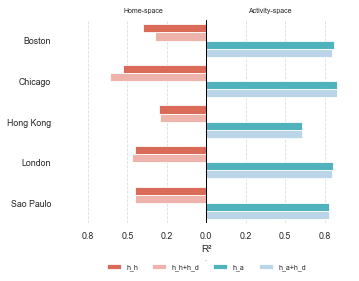

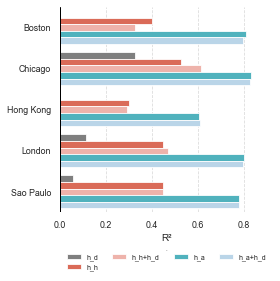

In [2]:
def plot_city_bar_summary(
    baseline_df: pd.DataFrame,
    metric: str = "R2",
    config_load: str = "15minw",
    include_person_only: bool = False,
):
    plot_df = baseline_df[baseline_df["config"] == config_load].copy()
    plot_df["sign"] = 1
    if not include_person_only:
        plot_df.loc[plot_df["type"].isin(["home_only", "home_person"]), "sign"] = -1
    plot_df[f"{metric}_mod"] = plot_df[metric] * plot_df["sign"]

    if include_person_only:
        categories = ["person_only", "home_only", "home_person", "visit_only", "visit_person"]
        legend_labels = ["h_d", "h_h", "h_h+h_d", "h_a", "h_a+h_d"]
        figsize = (4, 4)
        xlim = (0, plot_df[f"{metric}_mod"].max() + 0.1)
    else:
        categories = ["home_only", "home_person", "visit_only", "visit_person"]
        legend_labels = ["h_h", "h_h+h_d", "h_a", "h_a+h_d"]
        figsize = (5.1, 4)
        x_min = plot_df[f"{metric}_mod"].min() - 0.1
        x_max = plot_df[f"{metric}_mod"].max() + 0.1
        xlim = (min(x_min, -1 * abs(x_max)), max(abs(x_min), x_max))

    plot_df = plot_df[plot_df["type"].isin(categories)].copy()
    plot_df["type"] = pd.Categorical(plot_df["type"], categories=categories, ordered=True)
    plot_df["city_name"] = pd.Categorical(
        plot_df["city"].map(CITY_DICT),
        categories=list(CITY_DICT.values()),
        ordered=True,
    )

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=plot_df,
        y="city_name",
        x=f"{metric}_mod",
        hue="type",
        palette=type_colors,
        errorbar=None,
        ax=ax,
    )

    ax.axvline(x=0, color="black", linestyle="-", linewidth=1)
    ax.set_xlim(*xlim)
    if not include_person_only:
        ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{abs(x):.1f}"))

    metric_label = "R²" if metric == "R2" else metric
    ax.set_xlabel(metric_label, fontsize=10)
    ax.set_ylabel("")
    ax.set_title("", fontsize=10)

    if not include_person_only:
        ax.text(-0.4, -0.7, "Home-space", ha="center", fontsize=7)
        ax.text(0.4, -0.7, "Activity-space", ha="center", fontsize=7)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.xaxis.grid(True, linestyle="--", alpha=0.7)

    ax.legend(
        title="Type",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=4,
        fontsize=7,
        title_fontsize=0,
        frameon=False,
        labels=legend_labels,
    )
    fig.tight_layout()
    return fig, ax


fig4a_r2_bar, ax4a_r2_bar = plot_city_bar_summary(baseline_sel, metric="R2", config_load="15minw")
plt.show()

fig4a_r2_bar_demo, ax4a_r2_bar_demo = plot_city_bar_summary(
    baseline_sel,
    metric="R2",
    config_load="15minw",
    include_person_only=True,
)
plt.show()


## Income Group Lines


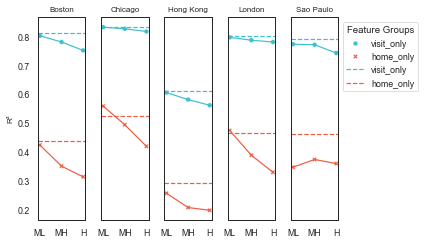

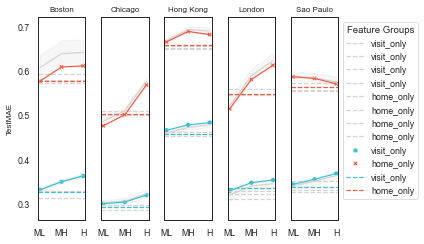

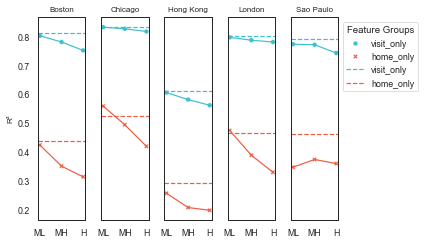

In [3]:
def plot_income_group_lines(
    viz_df_sel: pd.DataFrame,
    baseline_sel: pd.DataFrame,
    income_sel: int = 1,
    typels = ("visit_only", "home_only"),
    type_colors_line = type_colors_update,
    config_ls = ("15minw", "15min", "1260m", "1260mw"),
    metric: str = "R2",
    add_background: bool = False,
):
    viz_temp = viz_df_sel[
        (viz_df_sel["split"] == str(income_sel)) & (viz_df_sel["config"].isin(config_ls))
    ].reset_index(drop=True)
    viz_temp_other = viz_df_sel[viz_df_sel["split"] == str(income_sel)].reset_index(drop=True)

    fig, axes = plt.subplots(1, 5, figsize=(6, 3.5), sharey=True, sharex=True)
    for i, city in enumerate(city_enum):
        temp = viz_temp[(viz_temp["city"] == city) & (viz_temp["type"].isin(typels))].copy()
        temp["TestIncome"] = temp["TestIncome"].astype(str).map(income_dict)
        temp_other = viz_temp_other[
            (viz_temp_other["city"] == city) & (viz_temp_other["type"].isin(typels))
        ].copy()
        temp_other["TestIncome"] = temp_other["TestIncome"].astype(str).map(income_dict)

        if add_background:
            sns.lineplot(
                data=temp_other,
                x="TestIncome",
                y=metric,
                hue="type",
                palette={key: "lightgrey" for key in type_colors_line.keys()},
                ax=axes[i],
                legend=False,
            )
            base_other = baseline_sel[
                (baseline_sel["city"] == city) & (baseline_sel["type"].isin(typels))
            ].reset_index(drop=True)
            for j in range(len(base_other)):
                axes[i].axhline(
                    y=base_other[metric][j],
                    color="lightgrey",
                    linestyle="--",
                    label=base_other["type"][j],
                )

        sns.lineplot(
            data=temp,
            x="TestIncome",
            y=metric,
            hue="type",
            palette=type_colors_line,
            ax=axes[i],
            legend=False,
        )
        sns.scatterplot(
            data=temp,
            x="TestIncome",
            y=metric,
            hue="type",
            palette=type_colors_line,
            ax=axes[i],
            style="type",
            legend=(i == 4),
        )

        temp_base = baseline_sel[
            (baseline_sel["city"] == city)
            & (baseline_sel["type"].isin(typels))
            & (baseline_sel["config"].isin(config_ls))
        ].reset_index(drop=True)
        for j in range(len(temp_base)):
            axes[i].axhline(
                y=temp_base[metric][j],
                color=type_colors_line[temp_base["type"][j]],
                linestyle="--",
                label=temp_base["type"][j],
            )

        axes[i].set_title(CITY_DICT[city], fontsize=8)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("R²" if metric == "R2" else metric)
        if i == 4 and axes[i].legend_ is not None:
            axes[i].legend(title="Feature Groups", loc="upper left", bbox_to_anchor=(1, 1))
        elif axes[i].legend_ is not None:
            axes[i].legend_.remove()

    fig.tight_layout()
    return fig, axes


fig4b_r2_lines, axes4b_r2_lines = plot_income_group_lines(
    viz_df_sel,
    baseline_sel,
    income_sel=1,
    metric="R2",
    config_ls=("15min",),
    add_background=False,
)
plt.show()

fig4b_mae_lines, axes4b_mae_lines = plot_income_group_lines(
    viz_df_sel,
    baseline_sel,
    income_sel=1,
    metric="TestMAE",
    config_ls=("15min",),
    add_background=True,
)
plt.show()

fig4b_r2_lines_all, axes4b_r2_lines_all = plot_income_group_lines(
    viz_df_sel,
    baseline_sel,
    income_sel=1,
    metric="R2",
    config_ls=("15min",),
    add_background=False,
)
plt.show()


## Income Group Heatmaps


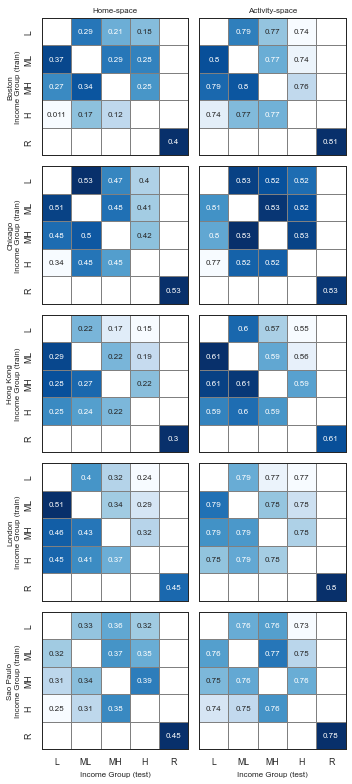

,City,Feature Group,Income Group (train),Income Group (test),R²,MAE,MSE
0,boston,Activity-space,1,2,0.786547,0.339614,0.216261
1,boston,Activity-space,1,3,0.765669,0.356942,0.237699
2,boston,Activity-space,1,4,0.737748,0.371670,0.259492
3,boston,Home-space,1,2,0.294854,0.643977,0.711887
4,boston,Home-space,1,3,0.205637,0.672300,0.805019


In [4]:
def build_income_group_export(
    viz_df_sel: pd.DataFrame,
    baseline_sel: pd.DataFrame,
    typels=("visit_only", "home_only"),
    config: str = "15minw",
):
    export = pd.concat(
        [
            viz_df_sel[viz_df_sel["type"].isin(typels)]
            .sort_values(by=["city", "split"], ascending=[True, True])
            .reset_index(drop=True),
            baseline_sel[baseline_sel["type"].isin(typels)]
            .sort_values(by=["city", "split"], ascending=[True, True])
            .reset_index(drop=True),
        ],
        axis=0,
    ).reset_index(drop=True)
    export = export[export["config"] == config].reset_index(drop=True)
    export = export[
        ["city", "type", "split", "TestIncome", "R2", "TestMAE", "TestLoss"]
    ].rename(
        columns={
            "TestIncome": "Income Group (test)",
            "R2": "R²",
            "TestMAE": "MAE",
            "TestLoss": "MSE",
            "city": "City",
            "type": "Feature Group",
            "split": "Income Group (train)",
        }
    )
    export["Feature Group"] = np.where(
        export["Feature Group"].str.contains("home"),
        "Home-space",
        "Activity-space",
    )
    return export


def plot_income_group_heatmaps(
    export: pd.DataFrame,
    metric: str = "R²",
    city_order = city_enum,
):
    fig, axes = plt.subplots(5, 2, figsize=(5, 11), sharey=True, sharex=True)
    for i, city in enumerate(city_order):
        for j, feature in enumerate(["Home-space", "Activity-space"]):
            viz = export[(export["Feature Group"] == feature) & (export["City"] == city)]
            viz = viz.pivot(
                index=["City", "Income Group (train)"],
                columns=["Income Group (test)"],
                values=metric,
            )
            sns.heatmap(
                viz,
                annot=True,
                annot_kws={"size": 8},
                cmap="Blues",
                cbar_kws={"label": metric},
                linewidths=0.5,
                linecolor="grey",
                xticklabels=["L", "ML", "MH", "H", "R"],
                yticklabels=["L", "ML", "MH", "H", "R"],
                ax=axes[i][j],
            )
            if j == 0:
                axes[i][j].set_ylabel(f"{CITY_DICT[city]}\nIncome Group (train)", fontsize=8)
            else:
                axes[i][j].set_ylabel("")
            if i == 4:
                axes[i][j].set_xlabel("Income Group (test)", fontsize=8)
            else:
                axes[i][j].set_xlabel("")
            if i == 0:
                axes[i][j].set_title(feature, fontsize=8)
            else:
                axes[i][j].set_title("")
            axes[i][j].collections[0].colorbar.remove()
            axes[i][j].spines["top"].set_visible(True)
            axes[i][j].spines["right"].set_visible(True)
            axes[i][j].spines["bottom"].set_visible(True)
            axes[i][j].spines["left"].set_visible(True)
    fig.tight_layout()
    return fig, axes


fig4_heatmap_table = build_income_group_export(
    viz_df_sel,
    baseline_sel,
    typels=("visit_only", "home_only"),
    config="15minw",
)
fig4c_heatmap, axes4c_heatmap = plot_income_group_heatmaps(fig4_heatmap_table, metric="R²")
plt.show()

fig4_heatmap_table.head()
